# Setup
In colab:

Go to "Runtime" -> "Change runtime type" -> Select "T4 GPU"
Install TerraTorch

In [1]:
%%time
# ── 1. Python deps ────────────────────────────────────────────────────────────
# terratorch 1.0.1 is what the notebooks were written against
# git-lfs is needed because the GeoTIFFs in examples/ are stored with LFS
!pip install --upgrade pip
!pip install terratorch==1.0.1 gdown git+https://github.com/huggingface/huggingface_hub
!pip install diffusers==0.30.0
!pip install torch

  Cloning https://github.com/huggingface/huggingface_hub to /tmp/pip-req-build-s_1n7gqv
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/huggingface_hub /tmp/pip-req-build-s_1n7gqv
  Resolved https://github.com/huggingface/huggingface_hub to commit 8318fe4e8791621ddb33bb3bd7c0d99d3eda53e4
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
CPU times: user 4.32 s, sys: 218 ms, total: 4.54 s
Wall time: 22.1 s


In [2]:
%%time
# ── 2. Pull the repo (only the examples/ folder) ──────────────────────────────
# --depth=1 keeps the clone quick;
# --branch selects the colab_compat branch
!git lfs install
!git clone --depth 1 --filter=blob:none --sparse \
      --branch colab_compat https://github.com/EugeneGene/terramind.git
# check out just the examples/ subtree  only
# cd back to root
%cd terramind
!git sparse-checkout set examples
%cd ..

Git LFS initialized.
fatal: destination path 'terramind' already exists and is not an empty directory.
/content/terramind
/content
CPU times: user 9.93 ms, sys: 1.94 ms, total: 11.9 ms
Wall time: 723 ms


In [3]:
%%time
# ── 3. Import Libraries relevant to this notebook ─────────────────────────────
import torch
import numpy as np
import rioxarray as rxr
import matplotlib.pyplot as plt
from terratorch import FULL_MODEL_REGISTRY
from terratorch.models.backbones.terramind.model.terramind_register import v1_pretraining_mean, v1_pretraining_std
import diffusers

CPU times: user 13.9 s, sys: 3.6 s, total: 17.5 s
Wall time: 21.5 s


In [4]:
%%time
# ── 5. Select device ──────────────────────────────────────────────────────────
if torch.cuda.is_available():
    device = 'cuda'
elif torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'
device

CPU times: user 25 µs, sys: 5 µs, total: 30 µs
Wall time: 34.3 µs


'cuda'

# Tokenizer Reconstruction
TerraMind includes internal tokenizers that convert raw geospatial data into latent tokens for learning and generation. In some use cases—especially for debugging, interpretation, or downstream model input—it is valuable to reconstruct and visualize the decoded data from these tokens. The Tokenizer Reconstructor enables this by reversing the tokenization process, mapping learned latent tokens back to spatially aligned, human-interpretable modalities such as satellite images or land cover maps.

This example demonstrates how to use the reconstruct_from_tokens function in TerraTorch to decode intermediate representations into full-resolution outputs.

In [5]:
%%time
model = FULL_MODEL_REGISTRY.build('terramind_v1_tokenizer_s2l2a', pretrained=True)
model.to(device)

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


CPU times: user 3.7 s, sys: 1.7 s, total: 5.4 s
Wall time: 9.12 s


DiVAE(
  (encoder): ViTEncoder(
    (proj): Conv2d(12, 768, kernel_size=(16, 16), stride=(16, 16))
    (blocks): Sequential(
      (0): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (norm2): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (attn): Attention(
          (qkv): Linear(in_features=768, out_features=2304, bias=True)
          (attn_drop): Dropout(p=0.0, inplace=False)
          (proj): Linear(in_features=768, out_features=768, bias=True)
          (proj_drop): Dropout(p=0.0, inplace=False)
        )
        (drop_path): Identity()
        (mlp): Mlp(
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (act): GELU(approximate='none')
          (fc2): Linear(in_features=3072, out_features=768, bias=True)
          (drop): Dropout(p=0.0, inplace=False)
        )
      )
      (1): Block(
        (norm1): LayerNorm((768,), eps=1e-06, elementwise_affine=True)
        (norm2): LayerNorm((768,), eps=

In [12]:
%%time
# Build model
model = FULL_MODEL_REGISTRY.build('terramind_v1_tokenizer_s2l2a', pretrained=True)

# For other modalities:
# model = FULL_MODEL_REGISTRY.build('terramind_v1_tokenizer_s1rtc', pretrained=True)
# model = FULL_MODEL_REGISTRY.build('terramind_v1_tokenizer_dem', pretrained=True)
#model = FULL_MODEL_REGISTRY.build('terramind_v1_tokenizer_lulc', pretrained=True)
# model = FULL_MODEL_REGISTRY.build('terramind_v1_tokenizer_ndvi', pretrained=True)

_ = model.to(device)

CPU times: user 3.96 s, sys: 925 ms, total: 4.89 s
Wall time: 5.04 s


In [13]:
%%time
#Load an example (Replace S2L2A in the file paths for other modalities)
examples = [
    'terramind/examples/S2L2A/38D_378R_2_3.tif',
    'terramind/examples/S2L2A/282D_485L_3_3.tif',
    'terramind/examples/S2L2A/433D_629L_3_1.tif',
    'terramind/examples/S2L2A/637U_59R_1_3.tif',
    'terramind/examples/S2L2A/609U_541L_3_0.tif',
]

# [TODO] LULC Reconstruction
# examples = [
#     'terramind/examples/LULC/38D_378R_2_3.tif',
#     'terramind/examples/LULC/282D_485L_3_3.tif',
#     'terramind/examples/LULC/433D_629L_3_1.tif',
#     'terramind/examples/LULC/637U_59R_1_3.tif',
#     'terramind/examples/LULC/609U_541L_3_0.tif',
# ]

# Select example between 0 and 4
data = rxr.open_rasterio(examples[1])
# Conver to shape [B, C, 224, 224]
data = torch.Tensor(data.values, device='cpu').unsqueeze(0)

CPU times: user 13.2 ms, sys: 1 µs, total: 13.2 ms
Wall time: 13 ms


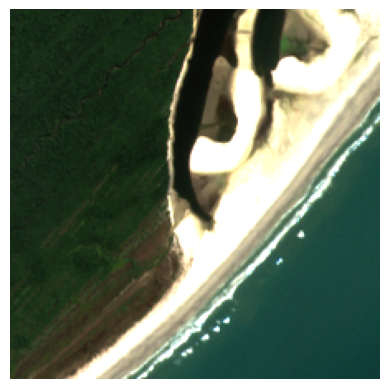

CPU times: user 102 ms, sys: 1.98 ms, total: 104 ms
Wall time: 105 ms


In [14]:
%%time
# Visualize S-2 L2A input as RGB
rgb = data[0, [3,2,1]].clone().permute(1,2,0)
rgb = (rgb / 2000).clip(0, 1) * 255
rgb = rgb.cpu().numpy().round().astype(np.uint8)
plt.imshow(rgb)
plt.axis('off')
plt.show()

In [15]:
# %%time
# [TODO] LULC Input and Reconstruction
# import matplotlib.colors as mcolors

# # Assume data is shape [1, 1, H, W] or [1, H, W]
# lulc = data.squeeze().cpu().numpy().astype(int)  # remove batch and channel dimensions

# # Define a color map and legend for known classes (adjust as needed)
# n_classes = lulc.max() + 1
# cmap = plt.get_cmap('tab20', n_classes)  # tab20 or any categorical colormap

# # Plot with colorbar
# plt.figure(figsize=(6,6))
# im = plt.imshow(lulc, cmap=cmap, interpolation='nearest')
# plt.axis('off')
# plt.colorbar(im, ticks=np.arange(n_classes))
# plt.title("LULC Classes")
# plt.show()


In [16]:
%%time
# Normalize input
mean = torch.Tensor(v1_pretraining_mean['untok_sen2l2a@224'])
std = torch.Tensor(v1_pretraining_std['untok_sen2l2a@224'])
input = (data - mean[None, :, None, None]) / std[None, :, None, None]

# See keys for other modalities:
v1_pretraining_mean.keys()

CPU times: user 2.14 ms, sys: 58 µs, total: 2.2 ms
Wall time: 3.4 ms


dict_keys(['untok_sen2l2a@224', 'untok_sen2l1c@224', 'untok_sen2rgb@224', 'untok_sen1grd@224', 'untok_sen1rtc@224', 'untok_dem@224', 'tok_sen1grd@224', 'tok_sen1rtc@224', 'tok_sen2l2a@224', 'tok_lulc@224', 'tok_dem@224', 'tok_ndvi@224'])

In [17]:
%%time
# Run model with diffusion steps
input = input.to(device)
with torch.no_grad():
    # Encode & decode image
    reconstruction = model(input, timesteps=10)

    # Alternatively split the encoding and decoding process to analyze tokens
    # Encode image
    # _, _, tokens = model.encode(input)
    # Decode tokens
    # reconstruction = model.decode_tokens(tokens, verbose=True, timesteps=10)

# Denormalize
reconstruction = reconstruction.cpu()
reconstruction = (reconstruction * std[None, :, None, None]) + mean[None, :, None, None]

100%|██████████| 10/10 [00:01<00:00,  7.20it/s]


CPU times: user 1e+03 ms, sys: 55.6 ms, total: 1.06 s
Wall time: 2.12 s


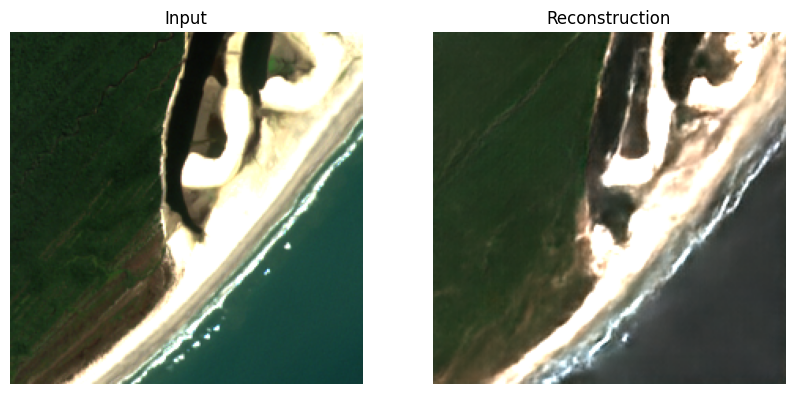

CPU times: user 234 ms, sys: 1.87 ms, total: 236 ms
Wall time: 236 ms


In [18]:
%%time
fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Visualize S-2 L2A input as RGB
rgb = data[0, [3,2,1]].clone().permute(1,2,0)
rgb = (rgb / 2000).clip(0, 1) * 255
rgb = rgb.cpu().numpy().round().astype(np.uint8)
ax[0].imshow(rgb)
ax[0].axis('off')
ax[0].set_title('Input')

# Visualize S-2 L2A reconstruction as RGB
rgb = reconstruction[0, [3,2,1]].clone().permute(1,2,0)
rgb = (rgb / 2000).clip(0, 1) * 255
rgb = rgb.cpu().numpy().round().astype(np.uint8)
ax[1].imshow(rgb)
ax[1].axis('off')
ax[1].set_title('Reconstruction')

plt.show()